In [1]:
import sklearn
from sklearn.metrics import roc_auc_score
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import json

In [68]:
from pathlib import Path

def load_all_json_by_name(folder_path):
    folder = Path(folder_path)
    data = {}

    for json_file in folder.glob("*.json"):
        
        with json_file.open("r", encoding="utf-8") as f:
            dataset, model = "", ""

            if 'llama-3b' in json_file.name:
                model = 'llama-3b'
            elif 'llama-8b' in json_file.name:
                model = 'llama-8b'
            elif 'qwen-0.5b' in json_file.name:
                model = 'qwen-0.5b'
            elif 'qwen-7b' in json_file.name:
                model = 'qwen-7b'
            else:
                raise ValueError(f"Unkonwn model: {json_file}")
                
            if 'ambig_qa_single' in json_file.name:
                dataset = 'ambig_qa_single'
            elif 'ambig_qa_multiple' in json_file.name:
                dataset = 'ambig_qa_multiple'
            elif 'trivia_qa' in json_file.name:
                dataset = 'trivia_qa'
            else:
                raise ValueError(f"Unkonwn dataset: {json_file}")

            data[json_file.name] = {'dataset': dataset, 'model': model, 'data': json.load(f)}
    return data

# Usage
data_by_name = load_all_json_by_name("data/rank_correlations")

headers = ['dataset', 'generator', 'judge family', 'judge', 'F1', 'Kendall', 'Spearman']
table = []

for k, v in data_by_name.items():
    # print(v['dataset'], v['model'])
    # print()
    for rec in v['data']['data']:        
        # print("\t", rec['judge'], rec['f1_score'], rec['rank_correlation_kendall']['kendalltau'])

        print(rec['judge_rankings'])
        jf = rec['judge'].split("_")[0]
        if jf == 'llm':
            jf = rec['judge'].split("_")[0] + "-" + rec['judge'].split("_")[-1]
        
        table.append([v['dataset'], v['model'],  jf, rec['judge'], rec['f1_score'], rec['rank_correlation_kendall']['kendalltau'], rec['rank_correlation_spearman']['spearmanr']])

[5, 1, 4, 6, 3, 7, 2]
[1, 4, 5, 6, 3, 7, 2]
[6, 5, 4, 1, 3, 2, 7]
[6, 4, 5, 1, 3, 2, 7]
[6, 4, 3, 5, 1, 2, 7]
[6, 4, 3, 5, 1, 2, 7]
[6, 4, 3, 5, 1, 2, 7]
[6, 5, 4, 1, 3, 2, 7]
[6, 4, 5, 3, 1, 2, 7]
[6, 4, 3, 5, 1, 2, 7]
[3, 5, 6, 1, 4, 7, 2]
[5, 3, 1, 4, 7, 6, 2]
[5, 4, 1, 6, 3, 7, 2]
[1, 3, 4, 5, 6, 7, 2]
[1, 4, 5, 3, 6, 7, 2]
[3, 5, 1, 4, 7, 6, 2]
[1, 3, 5, 7, 4, 2, 6]
[5, 1, 6, 4, 3, 2, 7]
[1, 6, 3, 4, 5, 7, 2]
[1, 3, 4, 6, 5, 7, 2]
[6, 3, 1, 4, 5, 2, 7]
[6, 1, 4, 3, 2, 5, 7]
[6, 1, 3, 4, 5, 2, 7]
[6, 1, 3, 5, 4, 7, 2]
[6, 1, 3, 5, 4, 2, 7]
[6, 1, 3, 5, 4, 2, 7]
[6, 1, 3, 4, 7, 2, 5]
[6, 3, 1, 4, 5, 2, 7]
[6, 3, 1, 4, 5, 2, 7]
[6, 3, 1, 4, 5, 2, 7]
[6, 3, 1, 4, 5, 7, 2]
[6, 3, 1, 4, 5, 7, 2]
[6, 4, 3, 2, 1, 5, 7]
[6, 4, 3, 2, 1, 5, 7]
[6, 4, 3, 2, 1, 5, 7]
[6, 4, 3, 2, 1, 5, 7]
[1, 6, 4, 3, 5, 2, 7]
[1, 6, 4, 5, 3, 2, 7]
[1, 6, 3, 4, 5, 7, 2]
[1, 3, 6, 4, 5, 7, 2]
[3, 6, 1, 5, 4, 7, 2]
[1, 6, 3, 5, 4, 7, 2]
[6, 3, 1, 4, 5, 2, 7]
[6, 4, 3, 2, 1, 5, 7]
[6, 4, 3, 2, 1, 5, 7]
[4, 1, 6, 

In [64]:
df = pd.DataFrame(
    table,
    columns=headers,
)
df

,dataset,generator,judge family,judge,F1,Kendall,Spearman
0,ambig_qa_multiple,qwen-7b,llm-os,llm_as_judge_correctness_os,0.776471,0.047619,0.071429
1,ambig_qa_multiple,qwen-7b,llm-api,llm_as_judge_correctness_api,0.894118,0.238095,0.250000
2,ambig_qa_multiple,qwen-7b,token,token_f1_0.1,0.393443,-0.238095,-0.142857
3,ambig_qa_multiple,qwen-7b,token,token_f1_0.2,0.230769,-0.142857,-0.107143
4,ambig_qa_multiple,qwen-7b,token,token_f1_0.3,0.042553,-0.142857,-0.107143
...,...,...,...,...,...,...,...
272,ambig_qa_single,qwen-0.5b,embedding,embedding_similarity_0.4,0.650000,0.714286,0.857143
273,ambig_qa_single,qwen-0.5b,embedding,embedding_similarity_0.5,0.740741,0.714286,0.857143
274,ambig_qa_single,qwen-0.5b,embedding,embedding_similarity_0.6,0.400000,0.142857,0.107143
275,ambig_qa_single,qwen-0.5b,embedding,embedding_similarity_0.7,0.315789,0.047619,0.000000


In [96]:

# df["annotation"] = pd.Categorical(df["annotation"].map({0: "Error", 1: "Correct"}), categories=["Correct", "Error"], ordered=True)
# df["label"] = pd.Categorical(df["label"].map({0: "Wrong", 1: "Correct"}), categories=["Correct", "Wrong"], ordered=True)
# df["judge"] = pd.Categorical(df["judge"].map({0: "Machine", 1: "Human"}), categories=["Human", "Machine"], ordered=True)
# df["UQ"] = pd.Categorical(df["UQ"].map({0: "Non-informative", 1: "Informative"}), categories=["Informative", "Non-informative"], ordered=True)

# df
!mkdir -p otherstuff

In [77]:
sns.plotting_context?

Signature: sns.plotting_context(context=None, font_scale=1, rc=None)
Docstring:
Get the parameters that control the scaling of plot elements.

These parameters correspond to label size, line thickness, etc. For more
information, see the :doc:`aesthetics tutorial <../tutorial/aesthetics>`.

The base context is "notebook", and the other contexts are "paper", "talk",
and "poster", which are version of the notebook parameters scaled by different
values. Font elements can also be scaled independently of (but relative to)
the other values.

This function can also be used as a context manager to temporarily
alter the global defaults. See :func:`set_theme` or :func:`set_context`
to modify the global defaults for all plots.

Parameters
----------
context : None, dict, or one of {paper, notebook, talk, poster}
    A dictionary of parameters or the name of a preconfigured set.
font_scale : float, optional
    Separate scaling factor to independently scale the size of the
    font elements.
rc : d

/var/folders/5n/kqrxk4_d27342m7xqqjhg42c0000gn/T/ipykernel_63389/569343634.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['dataset'] == 'trivia_qa'][df['generator'].isin(['qwen-7b', 'llama-8b'])],


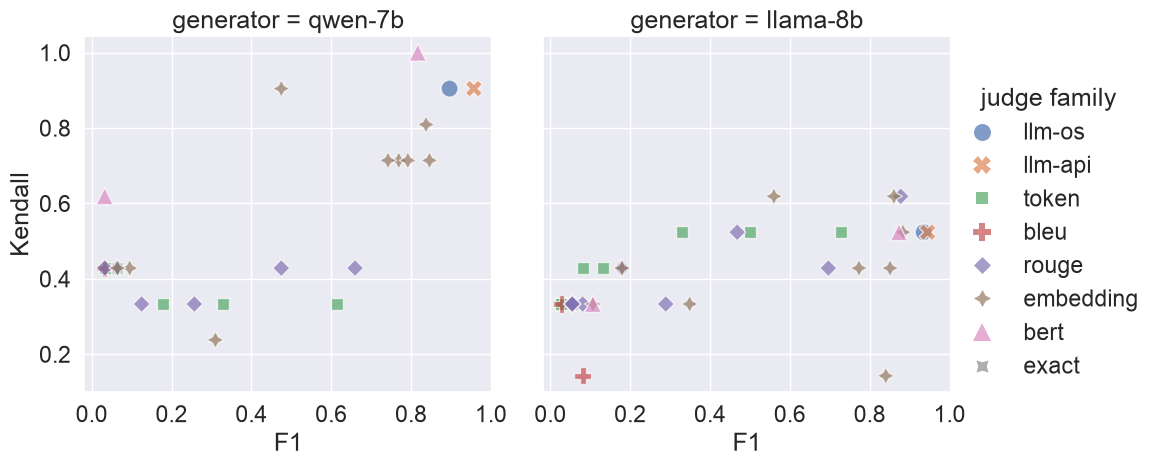

In [95]:
sns.set_theme(style="darkgrid")

with sns.plotting_context("notebook", font_scale=1.5):

    g= sns.relplot(
        df[df['dataset'] == 'trivia_qa'][df['generator'].isin(['qwen-7b', 'llama-8b'])],
        x='F1',
        y='Kendall',
        style='judge family',
        hue='judge family',
        # hue='UQ',
        # style='annotation',
        # row='dataset',
        col='generator',
        s=150,
        alpha=0.7
    )
g.savefig("otherstuff/F1")

In [48]:
sns.pairplot?

Signature:
sns.pairplot(
    data,
    *,
    hue=None,
    hue_order=None,
    palette=None,
    vars=None,
    x_vars=None,
    y_vars=None,
    kind='scatter',
    diag_kind='auto',
    markers=None,
    height=2.5,
    aspect=1,
    corner=False,
    dropna=False,
    plot_kws=None,
    diag_kws=None,
    grid_kws=None,
    size=None,
)
Docstring:
Plot pairwise relationships in a dataset.

By default, this function will create a grid of Axes such that each numeric
variable in ``data`` will by shared across the y-axes across a single row and
the x-axes across a single column. The diagonal plots are treated
differently: a univariate distribution plot is drawn to show the marginal
distribution of the data in each column.

It is also possible to show a subset of variables or plot different
variables on the rows and columns.

This is a high-level interface for :class:`PairGrid` that is intended to
make it easy to draw a few common styles. You should use :class:`PairGrid`
directly if you

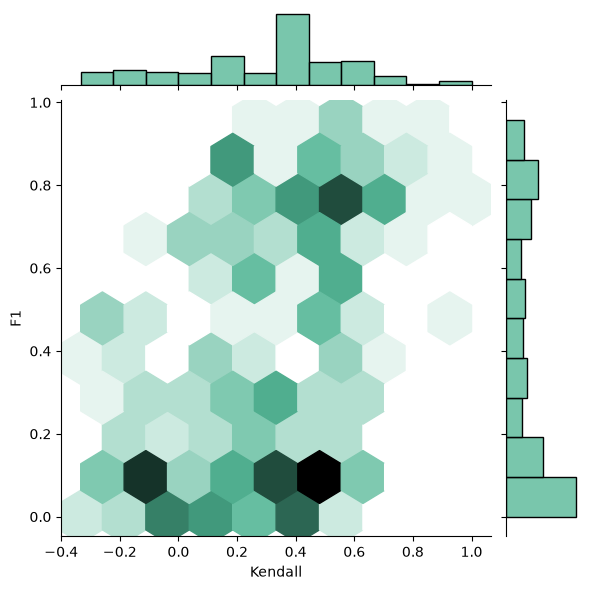

In [51]:
sns.jointplot(
    df, 
    x="Kendall", y="F1", kind="hex", color="#4CB391"
)

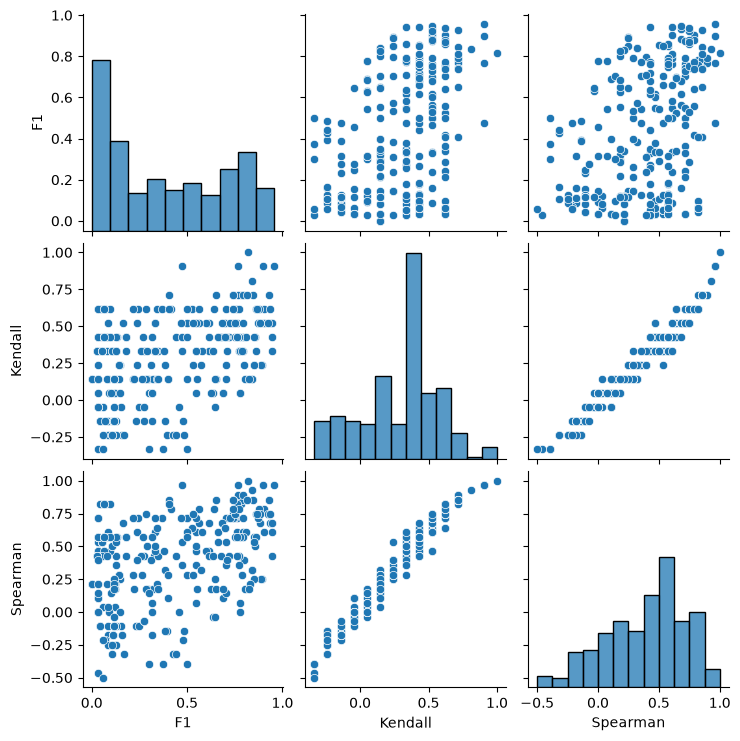

In [58]:
sns.pairplot(
    df
)

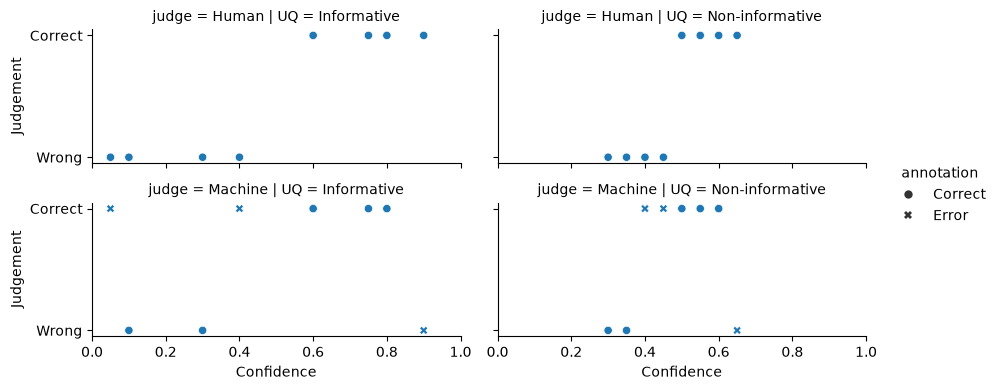

In [123]:

# g= sns.relplot(
#     df,
#     y='label',
#     x='confidence',
#     # style='label',
#     # hue='UQ',
#     style='annotation',
#     row='judge',
#     col='UQ',
# )
# for ax in g.axes.flat:
#     ax.set_xlim(0.0, 1.0)
#     # ax.set_xticks(np.arange(0.0, 1.01, 0.2))

# g.fig.set_size_inches(10, 4) 
# # g.axes[0,0].set_ylabel("Human judgement")
# # g.axes[1,0].set_ylabel("Machine judgement")
# g.set_ylabels("Judgement")
# g.set_xlabels("Confidence")
# # g.set(yticklabels=["False", "True"])
# _ = g.tight_layout()

In [20]:
# def draw(
#     ground_truth=np.array([0, 0, 0, 0, 1, 1, 1, 1]),
#     conf=np.array([0.05, 0.1, 0.3, 0.4, 0.6, 0.75, 0.8, 0.9]),
#     errors=np.array([0,0,0,0,0,0,0,0], dtype=bool)):    
#     pred = np.where(errors, 1-ground_truth, ground_truth)

    
#     df = pd.DataFrame(
#         np.stack([conf, ground_truth, pred, errors], -1),
#         columns=['confidence', 'human judgement', 'machine judgement', 'eval error']        
#     )
    
#     # errors = pred != ground_truth
#     # _ = plt.scatter(conf, ground_truth, c='gray', marker='s')
#     _ = plt.scatter(conf[ground_truth==1], np.ones_like(conf[ground_truth==1]), c='blue', marker='o', alpha=0.5)
#     _ = plt.scatter(conf[ground_truth==0], np.ones_like(conf[ground_truth==0]), c='blue', marker='x', alpha=0.5)

#     _ = plt.scatter(conf[np.logical_and(pred==1, pred==ground_truth)], np.zeros_like(conf[np.logical_and(pred==1, pred==ground_truth)]), c='blue', marker='o', alpha=0.5, label='TP')
#     _ = plt.scatter(conf[np.logical_and(pred==0, pred==ground_truth)], np.zeros_like(conf[np.logical_and(pred==0, pred==ground_truth)]), c='blue', marker='x', alpha=0.5, label='TN')
#     _ = plt.scatter(conf[np.logical_and(pred==1, pred!=ground_truth)], np.zeros_like(conf[np.logical_and(pred==1, pred!=ground_truth)]), c='red', marker='o', alpha=0.5, label='FP')
#     _ = plt.scatter(conf[np.logical_and(pred==0, pred!=ground_truth)], np.zeros_like(conf[np.logical_and(pred==0, pred!=ground_truth)]), c='red', marker='x', alpha=0.5, label='FN')
    
#     # _ = plt.scatter(conf[pred==0], np.zeros_like(conf[pred==0]), c='red', marker='x', alpha=0.5)

    
#     _ = plt.xlabel('Confidence')
#     _ = plt.ylabel('Groundtruth judgement')
#     _ = plt.yticks([0, 1], ['Machine judgement', 'Human judgement'])
#     _ = plt.xlim(-0.1, 1.1)
#     _ = plt.xticks([0., 0.2, 0.4, 0.6, 0.8, 1.])
#     _ = plt.legend(loc='center right')
#     _ = plt.title(f"Judge accuracy {1 - errors.mean():.2f} | AUROC {roc_auc_score(ground_truth, conf):.2f}->{roc_auc_score(pred, conf):.2f}")